In [1]:
import numpy as np
import matplotlib.pylab as plt

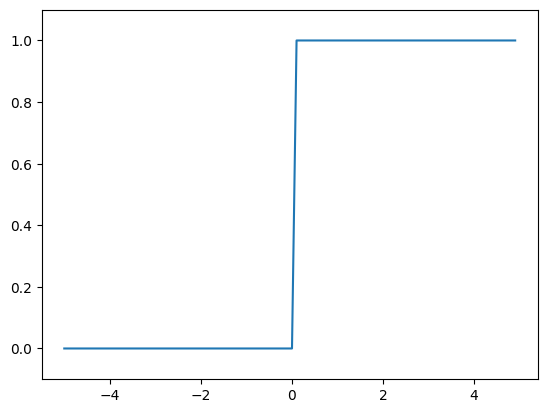

In [2]:
def step_function(x):
    return np.array(x > 0, dtype=np.int64)

x = np.arange(-5.0, 5.0, 0.1) # -5.0から5.0まで0.1刻みで生成
y = step_function(x)
plt.plot(x, y)
plt.ylim(-0.1, 1.1)
plt.show()

In [3]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

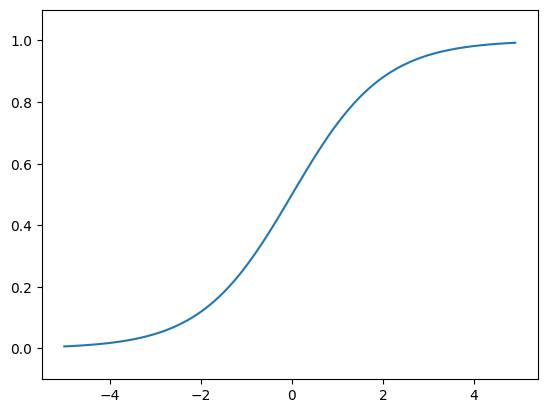

In [4]:
x = np.arange(-5.0, 5.0, 0.1) # -5.0から5.0まで0.1刻みで生成
y = sigmoid(x)
plt.plot(x, y)
plt.ylim(-0.1, 1.1)
plt.show()

In [5]:
def relu(x):
    return np.maximum(0, x)

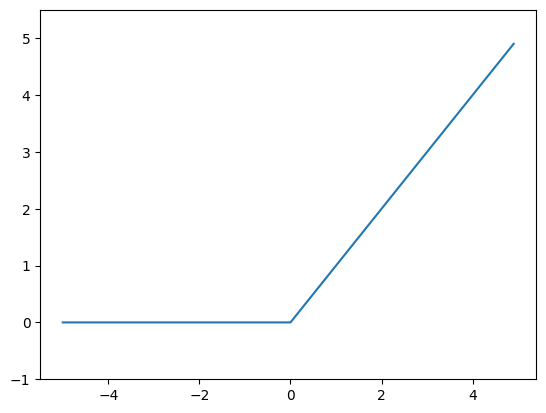

In [6]:
x = np.arange(-5.0, 5.0, 0.1) # -5.0から5.0まで0.1刻みで生成
y = relu(x)
plt.plot(x, y)
plt.ylim(-1, 5.5)
plt.show()

In [7]:
def identify_function(x):
    return x


def init_network():
    network = {}
    network['W1'] = np.array([[0.1, 0.3, 0.5], [0.2, 0.4, 0.6]])
    network['b1'] = np.array([0.1, 0.2, 0.3])
    network['W2'] = np.array([[0.1, 0.4], [0.2, 0.5], [0.3, 0.6]])
    network['b2'] = np.array([0.1, 0.2])
    network['W3'] = np.array([[0.1, 0.3], [0.2, 0.4]])
    network['b3'] = np.array([0.1, 0.2])
    
    return network


def forward(network, x):
    W1, W2, W3 = network['W1'], network['W2'], network['W3']
    b1, b2, b3 = network['b1'], network['b2'], network['b3']
    
    a1 = np.dot(x, W1) + b1
    z1 = sigmoid(a1)
    a2 = np.dot(z1, W2) + b2
    z2 = sigmoid(a2)
    a3 = np.dot(z2, W3) + b3
    y = identify_function(a3)
    
    return y

network = init_network()
x = np.array([1.0, 0.5])
y = forward(network, x)
print(y)

[0.31682708 0.69627909]


In [8]:
def softmax(a):
        exp_a = np.exp(a)
        sum_exp_a = np.sum(exp_a)
        y = exp_a / sum_exp_a
        
        return y

In [9]:
a = np.array([0.3, 2.9, 4.0])
print(softmax(a))

[0.01821127 0.24519181 0.73659691]


In [10]:
def softmax(a):
        c = np.max(a)
        exp_a = np.exp(a - c)
        sum_exp_a = np.sum(exp_a)
        y = exp_a / sum_exp_a
        
        return y

In [11]:
a = np.array([1010, 1000, 990])
print(softmax(a))

[9.99954600e-01 4.53978686e-05 2.06106005e-09]


In [12]:
np.sum(softmax(a))

1.0

In [13]:
import sys, os
sys.path.append(os.pardir)
from deep_learning_from_scratch_master.dataset.mnist import load_mnist

(x_train, t_train), (x_test, t_test) = \
    load_mnist(flatten=True, normalize=False)

print(x_train.shape)
print(t_train.shape)
print(x_test.shape)
print(t_test.shape)

(60000, 784)
(60000,)
(10000, 784)
(10000,)


In [14]:
import sys, os
sys.path.append(os.pardir)  # 親ディレクトリのファイルをインポートするための設定
import numpy as np
from deep_learning_from_scratch_master.dataset.mnist import load_mnist
from PIL import Image


def img_show(img):
    pil_img = Image.fromarray(np.uint8(img))
    pil_img.show()

(x_train, t_train), (x_test, t_test) = load_mnist(flatten=True, normalize=False)

img = x_train[0]
label = t_train[0]
print(label)  # 5

print(img.shape)  # (784,)
img = img.reshape(28, 28)  # 形状を元の画像サイズに変形
print(img.shape)  # (28, 28)

img_show(img)

5
(784,)
(28, 28)


In [15]:
import sys, os
sys.path.append(os.pardir)  # 親ディレクトリのファイルをインポートするための設定
import numpy as np
import pickle
from deep_learning_from_scratch_master.dataset.mnist import load_mnist
from deep_learning_from_scratch_master.common.functions import sigmoid, softmax


def get_data():
    (x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, flatten=True, one_hot_label=False)
    return x_test, t_test


def init_network():
    with open("deep_learning_from_scratch_master\ch03\sample_weight.pkl", 'rb') as f:
        network = pickle.load(f)
    return network


def predict(network, x):
    W1, W2, W3 = network['W1'], network['W2'], network['W3']
    b1, b2, b3 = network['b1'], network['b2'], network['b3']

    a1 = np.dot(x, W1) + b1
    z1 = sigmoid(a1)
    a2 = np.dot(z1, W2) + b2
    z2 = sigmoid(a2)
    a3 = np.dot(z2, W3) + b3
    y = softmax(a3)

    return y


x, t = get_data()
network = init_network()
accuracy_cnt = 0
for i in range(len(x)):
    y = predict(network, x[i])
    p= np.argmax(y) # 最も確率の高い要素のインデックスを取得
    if p == t[i]:
        accuracy_cnt += 1

print("Accuracy:" + str(float(accuracy_cnt) / len(x)))

<>:15: SyntaxWarning: invalid escape sequence '\c'
<>:15: SyntaxWarning: invalid escape sequence '\c'
C:\Users\RJC238\AppData\Local\Temp\ipykernel_18528\2528570436.py:15: SyntaxWarning: invalid escape sequence '\c'
  with open("deep_learning_from_scratch_master\ch03\sample_weight.pkl", 'rb') as f:


Accuracy:0.9352


In [16]:
import sys, os
sys.path.append(os.pardir)  # 親ディレクトリのファイルをインポートするための設定
import numpy as np
import pickle
from deep_learning_from_scratch_master.dataset.mnist import load_mnist
from deep_learning_from_scratch_master.common.functions import sigmoid, softmax


def get_data():
    (x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, flatten=True, one_hot_label=False)
    return x_test, t_test


def init_network():
    with open("deep_learning_from_scratch_master\ch03\sample_weight.pkl", 'rb') as f:
        network = pickle.load(f)
    return network


def predict(network, x):
    w1, w2, w3 = network['W1'], network['W2'], network['W3']
    b1, b2, b3 = network['b1'], network['b2'], network['b3']

    a1 = np.dot(x, w1) + b1
    z1 = sigmoid(a1)
    a2 = np.dot(z1, w2) + b2
    z2 = sigmoid(a2)
    a3 = np.dot(z2, w3) + b3
    y = softmax(a3)

    return y


x, t = get_data()
network = init_network()

batch_size = 100 # バッチの数
accuracy_cnt = 0

for i in range(0, len(x), batch_size):
    x_batch = x[i:i+batch_size]
    y_batch = predict(network, x_batch)
    p = np.argmax(y_batch, axis=1)
    accuracy_cnt += np.sum(p == t[i:i+batch_size])

print("Accuracy:" + str(float(accuracy_cnt) / len(x)))

<>:15: SyntaxWarning: invalid escape sequence '\c'
<>:15: SyntaxWarning: invalid escape sequence '\c'
C:\Users\RJC238\AppData\Local\Temp\ipykernel_18528\3311324929.py:15: SyntaxWarning: invalid escape sequence '\c'
  with open("deep_learning_from_scratch_master\ch03\sample_weight.pkl", 'rb') as f:


Accuracy:0.9352
